# Data Analysis 4: Curve Fitting

Fitting a function (or 'curve') to data is hugely important within both scientific and data-analytic fields. 

In this notebook we focus on the math that underlies curve-fitting by examining how to fit a straight line to data 


In [11]:
# Imports ...
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


# 1. Synthesizing Data

It will be useful for us to have some data to which we can later try to fit some data. 

In the cell below I create a function which generates x, y points corresponding to the equation 

$y = mx +c $

It will also (optionally) add "noise" to the data, slightly shifting the y-values of the points so that they are not exactly on the line. 


In [3]:
def linear(x, m, c):
    return m*x+c

def create_linear_data(n_points = 4 , m=1, c=0,  add_random_noise = False, sigma = 2.0 ):
    """
    Convenience function to create synthetic data for a linear model

    optional arguments 
    ------------------
    n_points: int
     - number of points to be made 
     
    m: float
     - the gradient of the line 
    c: float
     - the y-intercept of the line 
     
    add_random_noise: boolean
     - whether or not we want to add noise to the data 
     
    sigma: float
     - if we are adding noise, what standard-deviation do we want to use for the distribution of noise/uncertainty
    
    returns 
    ------------------
    x_values: np.array
     - of length n_points 
    y_values: np.array
     - of length n_points 
    """
    # Choose some x-values at which we will evaluate the function 
    x_values = np.random.default_rng().uniform(0,5,n_points)
    
    # Evaluate the y-values at the chosen x-values
    y_values = linear(x_values, m, c)
    
    # If desired, add some random "errors"/"noise"
    if add_random_noise:
        mu=0
        y_random = np.random.default_rng().normal(mu, sigma, n_points)
        y_values = y_values + y_random
    
    return x_values, y_values

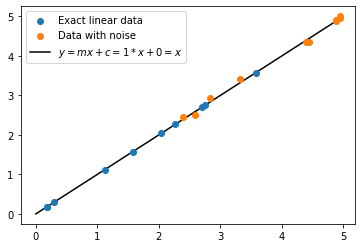

In [14]:
# create some data lying along a line:
# - "*exact" lies exactly on the line
# - "*data" lies close to the line, but has some noise/uncertainty that moves it slightly away from the line
x_exact, y_exact = create_linear_data(n_points = 10, m=1, c=0, add_random_noise = False)
x_data,  y_data  = create_linear_data(n_points = 10, m=1, c=0, add_random_noise = True, sigma = 0.1)

# plot the data we generated
plt.scatter(x_exact, y_exact, label='Exact linear data')
plt.scatter(x_data,  y_data, label='Data with noise')

# plot the line 
x = np.arange(0,5,0.1)
plt.plot(x, linear(x,1,0), label='$y = mx+c = 1*x + 0 = x$', c='k', zorder=0)
plt.legend()

# Exercise 4(A)
 - Use the `create_linear_data` function to create samples of 3 different sets of x & y data corresponding to 3 different choices for m & c in the equation $y=mx+c$
 - Vary the values of  `m` & `c`
 - Vary the degree of noise (controlled by `sigma`) 
 - Plot the 3 sets of data 
 - Ensure that the plots are labelled 

# 2: Minimizing the difference between a Model and the Data 

In the cells below, we step through the calculations required to 
1. quantify the difference between a model and data
2. refine/change the model to minimize the difference between the model and the data 

# 2.1 Guess an Initial Solution

x_data=[4.433532   4.87488596 2.5842461  2.39929036 4.94595757 4.93748747
 3.31071418 4.88440924 2.82972231 4.39846495]
y_data=[4.3483301  4.89209347 2.50788051 2.44948246 4.966745   5.00244268
 3.41656247 4.90158364 2.92644945 4.34969467]


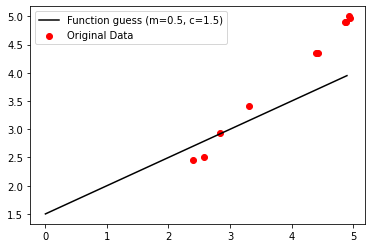

In [15]:
# Let's examine the values of x_data & y_data that we created above:
print(f'x_data={x_data}')
print(f'y_data={y_data}')

# We know that the x_data,y_data data created above is based on a model that had $m=1, c=0$
# Let's pretend we do NOT know that $m=1, c=0$
# Let's guess some possible values for $m$ & $c$, e.g. $m=0.5, c=1.5$
m_guess, c_guess = 0.5, 1.5 

# Let's plot the data & the solution-guess 
x_plot = np.arange(0,5,0.01)
plt.plot(x, linear(x,m_guess, c_guess), label=f'Function guess (m={m_guess}, c={c_guess})', c='k')
plt.scatter(x_data,y_data, label='Original Data', c='r')
plt.legend()

The guesses for the values of `m` & `c` were terrible!  
 - The function line goes nowhere near most of the data points!
    

# 2.2 Quantify the Difference Between the Model & the Data:
## - The Sum of the Squared Residuals
How terrible is the guess above ? 
 - We can quantify this by calculating how far each data point is from the corresponding value of the function with the guessed-parameters
 - I.e. we want to compare the values of `y_data` with the values of `y_guess = linear( x_data, m_guess, c_guess)`

y_diff =  [-0.99938709  0.18878866 -0.35600735 -0.11055204  0.66604307  0.13245761
 -0.52437566 -0.76938558 -0.06675021  0.26660191]


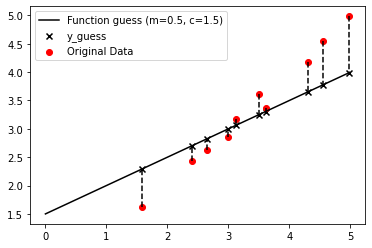

In [12]:
# Let's evaluate the `linear` function at $x=x_noise$ for $m_guess, c_guess = 0.5, 1.5 $
y_guess = linear( x_data, m_guess, c_guess)

# Let's plot the data & the solution-guess 
x_plot = np.arange(0,5,0.01)
plt.plot(x_plot, linear(x_plot, m_guess, c_guess), label=f'Function guess (m={m_guess}, c={c_guess})', c='k')
plt.scatter(x_data, y_guess, label='y_guess', c='k', marker='x')
plt.scatter(x_data, y_data, label='Original Data', c='r')
plt.legend()

# Let's calculate the *difference* :
y_diff = y_guess - y_data 
print( 'y_diff = ', y_diff )

# Let's plot the differences as some vertical lines ...
_ = plt.plot( (x_data, x_data), (y_data, y_guess), '--', c='black')

We want to understand how bad the *total/overall* difference is:
 - We can't just *sum* the differences (because negative and positive differences will cancel)
 - But we can *square* the differences and sum those
 - This is often referred to as "The sum of the squared residuals" 
 

In [13]:
# Calculate the sum of the squared residuals (sum of the squared differences)
sq = np.square(y_diff)
ssr = np.sum(sq)

print(f'Array of squared differences (residuals) ={sq}')
print(f'Sum of the array of squared residuals ={ssr}')

Array of squared differences (residuals) =[0.99877455 0.03564116 0.12674123 0.01222175 0.44361338 0.01754502
 0.27496984 0.59195417 0.00445559 0.07107658]
Sum of the array of squared values =2.576993261445579


# 2.3 Minimizing the Difference Between a Model & the Data:
# The *Least Squares* approach

If we can minimize the sum of the squared residuals, then we will be minimizing the difference between a model & the data.

I.e. we will arriving at the `best fit` parameters for that model to most closely describe the data.

E.g. we want to vary $m$ and $c$ until we minimize the value of $ssr$.

It does *not* mean that the fit will be perfect: 
 - In general the fitted line will *not* necessary go through every point (it will just come *close*)

This process of minimizing the difference between a model & the data by minimizing the sum of the squared residuals is refered to as a ["least squares"](https://en.wikipedia.org/wiki/Ordinary_least_squares) approach. 

## 2.3.1 Analytic Theory 

In the cells below we illustrate the math behind minimizing the sum of the squared residuals.

You can find further details at 
 - [https://en.wikipedia.org/wiki/Simple_linear_regression](https://en.wikipedia.org/wiki/Simple_linear_regression)
 - [https://en.wikipedia.org/wiki/Ordinary_least_squares](https://en.wikipedia.org/wiki/Ordinary_least_squares)

#### Straight line equation 
This is an *exact* relation between $x$ & $y$.

$y = \alpha + \beta x$


#### Change notation slightly 
Here we use subscripts to emphasize that we have *vectors*/*arrays* of `n` $x$ & $y$ values ($i=1...n$). 

This is still an exact relation between $x$ & $y$.

$y_i = \alpha + \beta x_i$


#### Allow for *errors* 
By including an $\epsilon_i$ term for every point, we allow the value of $y_i$ to differ from the exact model, $\alpha + \beta x_i$. 

$y_i = \alpha + \beta x_i + \epsilon_i$


#### Rearrange the equation

$\epsilon_i = y_i - \alpha - \beta x_i $


#### Square the equation and sum 
If we square and sum this expression, we are creating a quantity that is the same as the "Sum of the array of squared residuals" discussed above. 
For notational convenience, let's define this quantity as $S$, and write:

$
\begin{eqnarray}
S
&=& \Sigma_{i=1}^n \epsilon_i^2 \\
&=& \Sigma_{i=1}^n \left( y_i - \alpha - \beta x_i \right)^2 \\ 
&=& \Sigma_{i=1}^n \left( y_i^2 + \alpha^2 + \beta^2 x_i^2 - 2y_i\alpha - 2x_iy_i\beta  + 2\alpha\beta x_i \right) \\
\end{eqnarray}
$


To *minimise* we differentiate and set equal to zero: 

##### w.r.t. $\alpha$:

$
\begin{eqnarray}
0  
&=& \frac{\partial S}{\partial \alpha}  \\
&=& \Sigma_{i=1}^n \left(2\alpha - 2y_i + 2\beta x_i \right)   \\
&=& -2 \Sigma_{i=1}^n \left( y_i - \alpha - \beta x_i \right)  \\
&=& 2n\alpha -2 \Sigma_{i=1}^n \left( y_i - \beta x_i \right) \qquad \leftarrow \textrm{ used $\Sigma_{i=1}^n\alpha \equiv n\alpha$, because $\alpha$ is not dependent on $i$}  \\
&=& n\alpha - \Sigma_{i=1}^n \left( y_i - \beta x_i \right) \qquad \leftarrow \textrm{ divide by $2$}  \\
&=& n\alpha - \Sigma_{i=1}^n y_i + \beta \Sigma_{i=1}^n x_i  \qquad \leftarrow \textrm{ because $\beta$ is not dependent on $i$}  \\
n\alpha &=& \Sigma_{i=1}^n y_i - \beta \Sigma_{i=1}^n x_i \qquad \leftarrow \textrm{ rearrange} \\
\alpha &=& \frac{\Sigma_{i=1}^n y_i}{n} -\beta \frac{\Sigma_{i=1}^n x_i}{n} \qquad \leftarrow \textrm{ rearrange}\\ 
\alpha &=& {\bar y} - \beta {\bar x} \qquad \leftarrow \textrm{ because $\frac{\Sigma_{i=1}^n y_i}{n}  \equiv {\bar y}$, i.e. the average of the values of $y_i$} 
\end{eqnarray}
$


##### w.r.t. $\beta$:

$
\begin{eqnarray}
0
&=& \frac{\partial S}{\partial \beta}  \\
&=& \Sigma_{i=1}^n \left(2\beta x_i^2 - 2x_iy_i + 2\alpha x_i \right) \\
&=& -2 \Sigma_{i=1}^n x_i\left(y_i - \alpha - \beta x_i \right) \\
&=& \Sigma_{i=1}^n x_i\left(y_i - \alpha - \beta x_i \right)    \qquad \leftarrow \textrm{ divide by $-2$}  \\
&=& \Sigma_{i=1}^n x_i y_i - \alpha \Sigma_{i=1}^n x_i - \beta \Sigma_{i=1}^n x_i^2  \qquad \leftarrow \textrm{ because $\alpha$ & $\beta$ do not depend on $i$}\\
\alpha &=& \frac{ \Sigma_{i=1}^n x_i y_i  - \beta \Sigma_{i=1}^n x_i^2 }{\Sigma_{i=1}^n x_i } \qquad \leftarrow \textrm{ rearrange }\\
\end{eqnarray}
$


#### Solve the System of Equations:

The above gives us two equations, for two unknowns ($\alpha$ & $\beta$), so we can solve these equations: 

$
\begin{eqnarray}
{\bar y} - \beta {\bar x}
&=& \frac{ \Sigma_{i=1}^n x_i y_i  - \beta \Sigma_{i=1}^n x_i^2 }{\Sigma_{i=1}^n x_i } 
\\ 
\frac{\beta \Sigma_{i=1}^n x_i^2}{\Sigma_{i=1}^n x_i } - \beta {\bar x} 
&=& \frac{ \Sigma_{i=1}^n x_i y_i }{\Sigma_{i=1}^n x_i } - {\bar y}
\qquad \leftarrow \textrm{ rearranged}
\\ 
\beta\Sigma_{i=1}^n x_i^2 - \beta{\bar x}\Sigma_{i=1}^n x_i 
&=&  \Sigma_{i=1}^n x_i y_i  - {\bar y}\Sigma_{i=1}^n x_i
\qquad \leftarrow \textrm{ multiplied by $\Sigma_{i=1}^n x_i$}
\\
\beta
&=&  \frac{\Sigma_{i=1}^n x_i y_i  - {\bar y}\Sigma_{i=1}^n x_i}{\left(\Sigma_{i=1}^n x_i^2 - {\bar x}\Sigma_{i=1}^n x_i\right)}
\\
&=&  \frac{\Sigma_{i=1}^n x_i y_i  - n{\bar x}{\bar y}}{\left(\Sigma_{i=1}^n x_i^2 - n{\bar x}^2\right)}
\qquad \leftarrow \textrm{ because $n{\bar x} \equiv \Sigma_{i=1}^n x_i $ }
\\
\end{eqnarray}
$


At this point we are basically finished, as we now have expressions for $\alpha$ and $\beta$ that are purely in terms of $x_i$ and $y_i$ (and also ${\bar x}$ and ${\bar y}$), hence we cam calculate everything. 

One finally step we will make is to note that the above equation for $\beta$ can be rewritten in the following format that is frequently quoted: 

$\beta = \frac{\sum (x - \bar{x})(y - \bar{y})}{\sum (x - \bar{x})^2}$

To see that these expressions are equivalent requires us to explicitly expand the summations as follows ... 

$
\begin{eqnarray}
\Sigma \left( \left( x_i - \bar{x}\right)\left( y_i - \bar{y}\right)\right)
&=&  
\Sigma \left( x_iy_i - \bar{x}y_i - \bar{y}x_i +\bar{x}\bar{y}\right) \\
&=&  
\Sigma x_iy_i - \bar{x}\Sigma y_i - \bar{y}\Sigma x_i +\bar{x}\bar{y}\Sigma 1 \\
&=&  
\Sigma x_iy_i - n\bar{x}\bar{y} - n\bar{x}\bar{y}\Sigma x_i +n\bar{x}\bar{y} \\
&=&  
\Sigma x_iy_i - n\bar{x}\bar{y} 
\\
\Sigma \left( \left( x_i - \bar{x}\right)\left( x_i - \bar{x}\right)\right)
&=&  
\Sigma \left( x_ix_i - \bar{x}x_i - \bar{x}x_i +\bar{x}\bar{x}\right) \\
&=&  
\Sigma x_ix_i - \bar{x}\Sigma x_i - \bar{x}\Sigma x_i +\bar{x}\bar{x}\Sigma 1 \\
&=&  
\Sigma x_ix_i - n\bar{x}\bar{x} - n\bar{x}\bar{x}\Sigma x_i +n\bar{x}\bar{x} \\
&=&  
\Sigma x_ix_i - n\bar{x}\bar{y} \\
&=&  
\Sigma x_i^2 - n\bar{x}^2 \\
\end{eqnarray}
$


#### In summary

After all of the above, we get to: 

$\alpha = \bar{y} - \beta*\bar{x}$

$\beta = \frac{\sum (x - \bar{x})(y - \bar{y})}{\sum (x - \bar{x})^2}$


# Exercise 4 (B)

a. Create a function which uses the approach described in Section 2.3.1 to calculate $\alpha$ & $\beta$ for input arrays of `x` & `y` data
b. Use your function to find the best fit to the following data:
   - x = np.array( [1,2,3,4,5,6] ) ,  
   - y = np.array( [21,20,19,18,17,16] )
c. Plot the data and the line that can be drawn using the fitted values of $\alpha$ & $\beta$ 
d. Repeat (b) & (c) for the data 
   - x = np.array( [1,2,3,4,5,6] ) ,  
   - y = np.array( [21.2,19.9,18.8,18.1,17.2,15.8] )

## 2.3.2 Existing Methods 

There are multiple tools that have been created that you can use to find the *best fit* to some data.

Here we will look at the `fit` function from the `numpy.polynomial.Polynomial` package, and the `curve_fit` function from the `scipy` package. 

### (A) numpy.polynomial.Polynomial.fit
 - See documentation at [https://numpy.org/doc/stable/reference/routines.polynomials.html](https://numpy.org/doc/stable/reference/routines.polynomials.html)
 
The `fit` function can be used to fit any *polynomial* you like to a set of data.
We will choose a very simple polynomial of *degree = 1*:
 - I.e. a straight line 

NB(1) The `fit` function returns a `Polynomial` object as a way to represent the fitted function.
 - In the cell below we show an example of a polynomial object
 
NB(2) Unhelpfully, the returned coefficients are a scaled version of what you want. In order to get the expected coefficients we have to use the `convert` function. 

NB(3): There are lots of online documents refering to `numpy.poly` and `numpy.polyfit`. There is nothing wrong with using these functions but you should be aware that, 
 - These functions are regarded as old/legacy, and that it is a good idea to use the more recent code, `np.polynomial.Polynomial` or `np.polynomial.Polynomial.fit`
 - The older functions do NOT have exactly the same syntax as the new functions (see [https://numpy.org/doc/stable/reference/routines.polynomials.html](https://numpy.org/doc/stable/reference/routines.polynomials.html) for more details)

#### A python `Polynomial` object 

In [34]:
# Example of a `Polynomial` object 
p = np.polynomial.Polynomial([3, 2, 1])
print('p=',p)
print('type(p)=', type(p))

# Polynomial objects are clever: they work like functions if you pass in some x-values ...
x = np.array( [0,1,2,3,4,5,] )
print( ' p(x) = ' , p(x) )

p= 3.0 + 2.0·x + 1.0·x²
type(p)= <class 'numpy.polynomial.polynomial.Polynomial'>
 p(x) =  [ 3.  6. 11. 18. 27. 38.]


#### Using the python `Polynomial.fit` function 

In [35]:
# Example of using `fit` 
result = np.polynomial.Polynomial.fit(x_data, y_data, deg=1)
print('Unhelpful `scaled` coefficients: ',result)
print('The fitted coefficients that we want: ',result.convert())
print('type(result)=', type(result))


Unhelpful `scaled` coefficients:  3.69166048 + 1.26100538·x
The fitted coefficients that we want:  0.05459431 + 0.99031815·x
type(result)= <class 'numpy.polynomial.polynomial.Polynomial'>


#### Plot the results

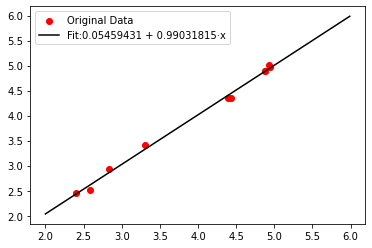

In [31]:
# Plot the fitted line and the data ...
plt.scatter(x_data,y_data, label='Original Data', c='r')
xp = np.arange(2,6,0.01)
plt.plot(xp, result(xp),label=f'Fit:{result.convert()}', c='k')
plt.legend()

### (B) scipy.optimize.curve_fit
 - See [https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)
 
 The `curve_fit` function from the `scipy` package performs the same task as the `fit` function above, but it has a different syntax.
 
 To start with, you have to define a function that is of the form you want to fit. 
  - The function *must* be specified such that the independent ('x') variable is the first argument
  - The function *must* be specified such that the parameters to be varied are the rest of the arguments
  - We define our linear function below ...

In [1]:
# Define a linear function that we will pass in to curve_fit
# NB: This is exactly the same as defined at the top of the notebook...
# - I'm just redefining it here to make it easier to see 
def linear(x,m,c):  
    return m*x+c

#### Using the python `scipy.optimize.curve_fit` function 
When we do the fitting, we pass the name of the model function (in our case `linear`) to the `curve_fit` function as an argument (see `curve_fit(linear, ...)` below).

In [42]:
# Call the curve_fit function, using the function, `f`, defined above, along with the x & y data 
from scipy.optimize import curve_fit
popt, pcov = curve_fit(linear, x_data, y_data)
print(f'popt = Optimal values for the parameters = {popt}')

popt = Optimal values for the parameters = [0.99031815 0.05459431]


#### Plot the results

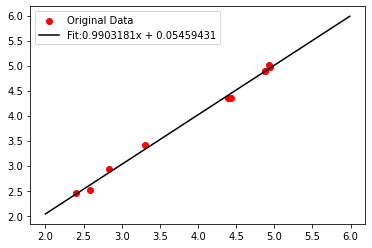

In [43]:
# Plot the fitted line and the data ...
plt.scatter(x_data,y_data, label='Original Data', c='r')
xp = np.arange(2,6,0.01)
plt.plot(xp, linear(xp,*popt),label=f'Fit:{popt[0]:.7}x + {popt[1]:.7}', c='k')
plt.legend()

### Comparing `curve_fit` and `Polynomial.fit` 
 - We see from the above that the numerical results from the fit are the same 
 - There are just some differences in  
   - (a) the way that you have to set up the functions to use them, 
   - (b) the way that the functions report their results

# Exercise 4 (C)

The cell below contains arrays of x,y data that lie close to (but not on) a *quadratic* curve.

1. Use either the `scipy.optimize.curve_fit` or `numpy.polynomial.Polynomial.fit` functions to find the best-fit quadratic coefficients for these data. 

2. Use the returned coefficients to plot the best-fit line & the data points (`x_ex4c`,`y_ex4c`)

In [ ]:
# x,y data that lie close to (but not on) a quadratic curve
x_ex4c = np.array([4.03255546 4.01503306 0.67117595 1.12848146 4.34841011 1.67258005
 0.26163066 0.43559121 2.92941961 4.47514035 3.36714559 2.92814924
 2.44332827 1.07793413 0.21018937 3.40578198 4.94226773 0.28899509
 3.98585743 0.89403024 4.69620543 2.80815159 1.00180175 3.00488499
 4.22833602 1.51752665 2.50377446 1.66959998 2.08757228 3.97155137
 1.87806512 4.40984697 4.11585901 4.96281554 4.41404286 3.1453944
 2.75897411 1.14147064 2.08285434 4.6874899  3.4894368  2.73683185
 4.62809443 1.40909375 4.15479524 4.9231119  2.72996466 0.77152449
 2.99862631 1.72192765 2.0869166  0.89890601 2.65595934 0.01315743
 3.15938597 2.53247933 3.26893875 1.99026511 3.60793436 0.75395311
 0.67989158 0.35249647 0.35145153 2.29987602 0.63014503 0.95991315
 4.44029497 3.26352609 2.18942273 1.67999505 2.90221318 2.69620813
 4.20765987 4.3514644  3.23321388 3.73717317 4.36431536 0.19796672
 1.01545915 2.19744355 3.9113072  3.86112554 0.43374079 2.54729685
 1.52061393 4.16738911 1.02252868 1.44425098 2.00714169 0.55797645
 2.53331459 0.03715854 4.66851552 2.45738795 4.99621417 1.14586025
 1.81748988 2.98009611 2.34770653 1.42928174])
y_ex4c = np.array([ 3.95858327  2.76131128  7.2858617   4.86326093  3.3061101   3.41301702
 10.39950116  8.90057514  2.51323243  4.02552272  2.08462704  1.71881669
  1.88888798  5.40405248  8.48435874  2.02826836  5.98761206  8.93271853
  2.85194703  6.20816185  4.74120687  0.99330807  5.84695944  1.732042
  2.99462057  4.06364301  2.04102674  3.32823968  2.66834221  2.97657898
  3.29968619  3.17079488  3.11663428  5.50790891  4.38881688  1.52815955
  2.77219953  4.89080152  2.81555957  4.57141334  1.89974478  1.30335164
  4.71489266  4.34390373  2.49860971  5.97204245  2.1343939   7.00851804
  2.63197321  3.63724449  3.19717929  5.85302989  1.62555717 11.0347339
  1.43803325  2.51293347  2.16856344  2.08479713  1.92191822  7.30744505
  6.91793326  9.00681928  8.55462237  2.68275752  7.75499644  6.61071101
  4.57449257  1.55448105  3.60832259  3.20893813  3.12095506  1.54550222
  3.63313593  4.13278853  2.30458833  3.07191061  4.70143841 10.07487277
  6.20671279  3.12842527  3.41356252  2.6346176   8.86375479  1.58709698
  4.60555618  3.43898266  6.16550158  3.94898191  3.07279356  8.06543158
  1.35353507 10.45563829  4.79372677  3.59314374  6.43511041  5.55268582
  3.38711826  1.38325734  2.03336417  3.94514496])